In [2]:
from gd_plots import *
import copy
import math
import numpy as np
import matplotlib.pyplot as plt

In [5]:
x_train = np.array([1.0, 2.0])
y_train = np.array([300.0, 500.0])

m = len(x_train)

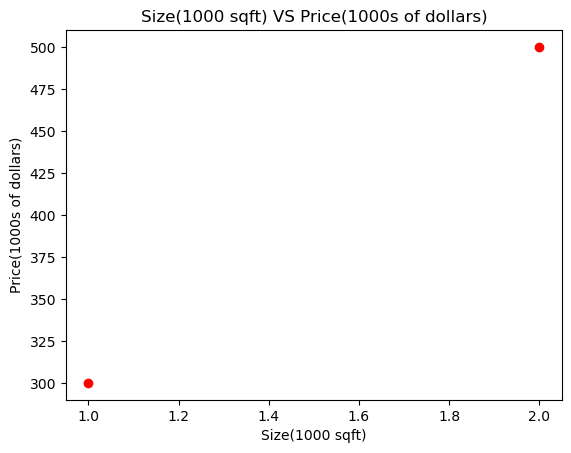

In [8]:
# visualizing data
plt.title("Size(1000 sqft) VS Price(1000s of dollars)")
plt.xlabel("Size(1000 sqft)")
plt.ylabel("Price(1000s of dollars)")
plt.scatter(x_train, y_train, c='r', marker='o')
plt.show()

In [10]:
def compute_cost(x, y, w, b):
    cost = 0
    m = len(x)
    for i in range(m):
        cost += ((x[i] * w + b) - y[i]) ** 2
    cost /= 2 * m

    return cost

In [12]:
def compute_gradient(x, y, w, b):
    dj_dw = 0
    dj_db = 0
    m = len(x)

    for i in range(m):
        dj_dw += ((x[i] * w + b) - y[i]) * x[i]
        dj_db += ((x[i] * w + b) - y[i])

    dj_dw /= m
    dj_db /= m

    return dj_dw, dj_db

In [13]:
def gradient_descent(x, y, w_in, b_in, alpha, iterations, threshold):
    j_history = [] # history of cost function
    p_history = [] # history of paramerts w and b
    w, b = w_in, b_in
    
    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(x, y, w, b)
        w = w - (alpha * dj_dw)
        b = b - (alpha * dj_db)

        j_history.append(compute_cost(x, y, w, b))
        p_history.append([w, b])

        # printing every 1000's
        if i % math.ceil(iterations/10) == 0:
            print(f"Iteration:{i}, Cost:{j_history[i]:.4f}, dj_dw:{dj_dw:.4f}, dj_db:{dj_db:.4f}, w:{w:.3f}, b:{b:.3f}")
        if (abs(dj_dw) <= threshold and abs(dj_db) <= threshold):
            break



    return w, b, j_history, p_history
                
    
        

In [36]:
w_in = 0
b_in = 0
iterations = 10000
threshold = 0.001
learning_rate = 0.01

final_w, final_b, j_history, p_history = gradient_descent(x_train, y_train, w_in, b_in, learning_rate, iterations, threshold)

Iteration:0, Cost:79274.8125, dj_dw:-650.0000, dj_db:-400.0000, w:6.500, b:4.000
Iteration:1000, Cost:3.4125, dj_dw:-0.3712, dj_db:0.6007, w:194.915, b:108.228
Iteration:2000, Cost:0.7929, dj_dw:-0.1789, dj_db:0.2895, w:197.549, b:103.966
Iteration:3000, Cost:0.1842, dj_dw:-0.0863, dj_db:0.1396, w:198.818, b:101.912
Iteration:4000, Cost:0.0428, dj_dw:-0.0416, dj_db:0.0673, w:199.430, b:100.922
Iteration:5000, Cost:0.0099, dj_dw:-0.0200, dj_db:0.0324, w:199.725, b:100.444
Iteration:6000, Cost:0.0023, dj_dw:-0.0097, dj_db:0.0156, w:199.868, b:100.214
Iteration:7000, Cost:0.0005, dj_dw:-0.0047, dj_db:0.0075, w:199.936, b:100.103
Iteration:8000, Cost:0.0001, dj_dw:-0.0022, dj_db:0.0036, w:199.969, b:100.050
Iteration:9000, Cost:0.0000, dj_dw:-0.0011, dj_db:0.0018, w:199.985, b:100.024


In [37]:
len(j_history)

9769

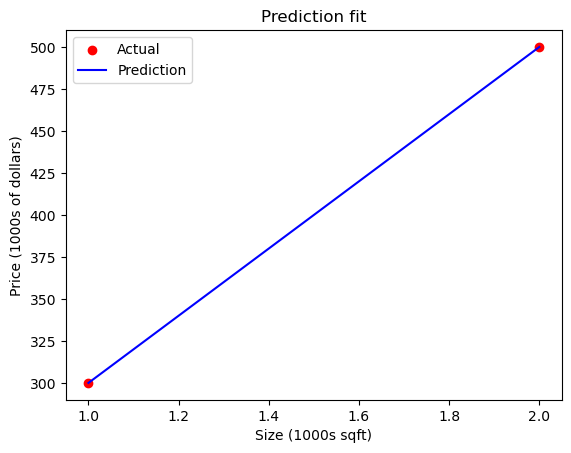

In [48]:
plt.title("Prediction fit")
plt.xlabel("Size (1000s sqft)")
plt.ylabel("Price (1000s of dollars)")
plt.scatter(x_train, y_train, marker='o', c='r', label="Actual")
plt.plot(x_train, final_w * x_train + final_b, c='b', label="Prediction")
plt.legend()
plt.show()



In [50]:
print(f"price of 1400 sqft is ${(1.4 * final_w + final_b) * 1000:.2f}")

price of 1400 sqft is $380001.84
